In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters
from skimage.io import imread
from skimage.feature import corner_peaks
from preprocessing import *
from solver import solve_sudoku, display_board, is_valid_sudoku

In [35]:
def display_image_grayscale(image, title="Image"):
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_image_color(image, title="Image"):
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

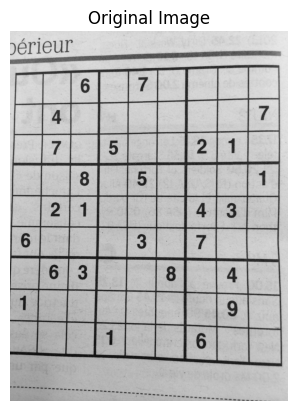

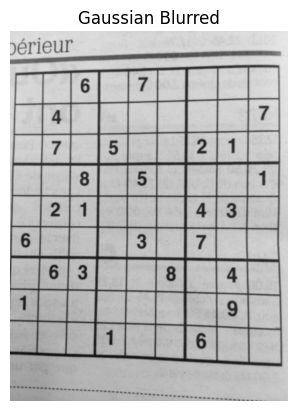

In [36]:
image = cv2.imread("images/image1000.jpg", cv2.IMREAD_GRAYSCALE)
L = 5
box_kernel = np.ones((L, L)) / (L**2)
gaussian_kernel = create_gaussian_kernel(9)

blurred_image = linear_filter(image, box_kernel)
median_filter_image = median_filter(image, L)
gaussian_image = linear_filter(image, gaussian_kernel)

display_image_grayscale(image, "Original Image")
display_image_grayscale(gaussian_image, "Gaussian Blurred")

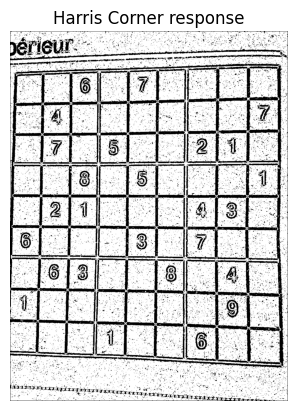

In [37]:
# Compute Harris corner response
response = harris_corners(image)
display_image_grayscale(response, "Harris Corner response")

Text(0.5, 1.0, 'Detected Corners')

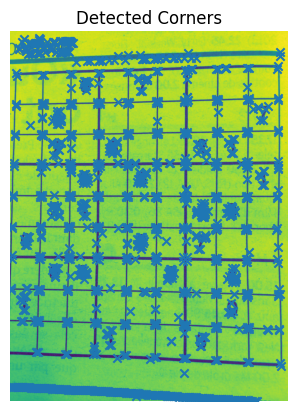

In [38]:
corners = corner_peaks(response, threshold_rel=0.01)
# Display detected corners
plt.imshow(image)
plt.scatter(corners[:,1], corners[:,0], marker='x')
plt.axis('off')
plt.title('Detected Corners')

In [39]:
sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

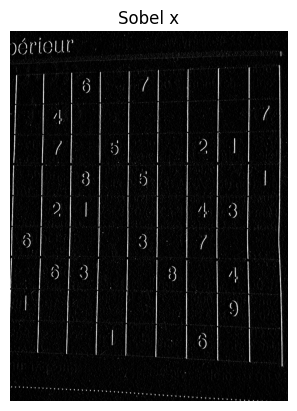

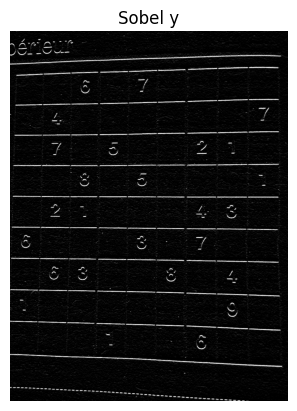

In [40]:
image_sobel_x = linear_filter(image, sobel_x_kernel)
image_sobel_y = linear_filter(image, sobel_y_kernel)
display_image_grayscale(image_sobel_x, "Sobel x")
display_image_grayscale(image_sobel_y, "Sobel y")

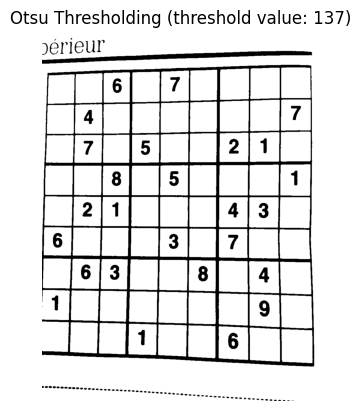

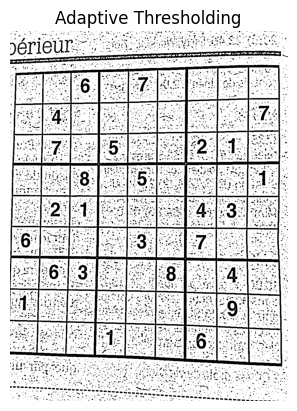

In [41]:
(hist, bin) = create_histogram(gaussian_image, 256, is_normalized=False)
threshold_val = find_otsu_threshold(hist)
image_thresh = perform_global_threshold(gaussian_image, threshold_val)
display_image_grayscale(image_thresh, f"Otsu Thresholding (threshold value: {threshold_val})")
display_image_grayscale(apply_adaptive_threshold(gaussian_image, 11, 1), "Adaptive Thresholding")

## Preprocessing and Perspective Transform

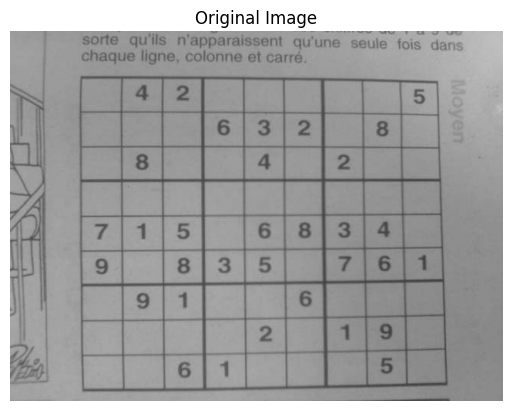

[ 1.07557221e+00 -6.17476877e-04  9.22997194e+01]
[1.84048988e-02 8.88611404e-01 5.81889535e+01]
[ 7.80989918e-05 -5.41099075e-05  1.00325782e+00]


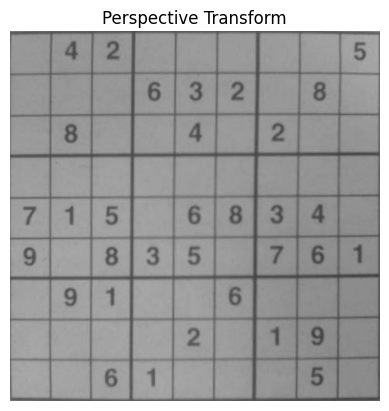

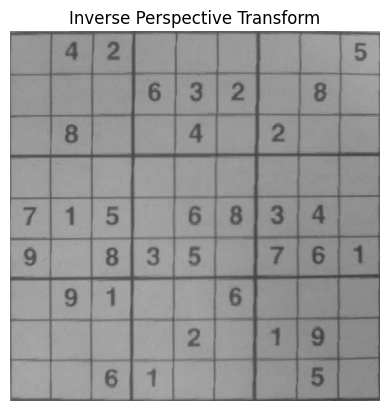

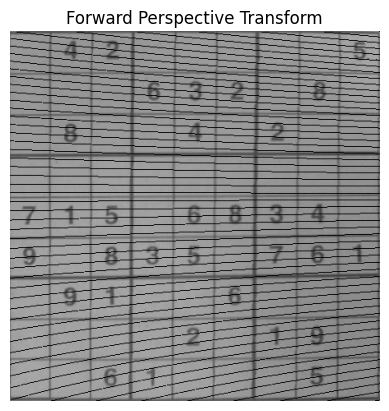

In [ ]:
# Replace with image path
image_path = "data/sudoku_dataset/images/image10.jpg" 
# image_path = "images/image1031.jpg"

# Read the image in grayscale
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
display_image_grayscale(img, "Original Image")
if img is None:
    raise ValueError("Image not found. Check the path.")

original = img.copy()

# Pre-process: Blur and Adaptive Thresholding
# Gaussian blur reduces high-frequency noise
gaussian_kernel = create_gaussian_kernel(9, 1.6)
blurred = linear_filter(img, gaussian_kernel, is_clipped=True)

# Thresholding
thresh = apply_adaptive_threshold(blurred, 11, 2, is_inverse=True)

# Find contours (I don't think we can build custom version)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # Suzuki Abe algorithm

# Assume the Sudoku board is the largest contour by area
# largest_contour = max(contours, key=cv2.contourArea) # replace this with find_area function

contours = sorted(contours, key=cv2.contourArea, reverse=True)

grid_contour = None
for contour in contours[:5]:
    contour = contour[:,0,:]
    perimeter = find_arc_length(contour, is_closed=True)
    epsilon = 0.02 * perimeter
    approx = approximate_polygon(contour, epsilon, is_closed=True)
    if len(approx) == 4:
        grid_contour = approx
        break

if grid_contour is None:
    raise ValueError("Could not find 4 corners of the Sudoku board. Try better lighting.")


# Perspective Transform (Flatten the board)
rect = order_points(grid_contour)

# Create a perfect square image to map the board to (450x450 is easily divisible by 9)
side_length = 450
dst = np.array([
    [0, 0],
    [side_length - 1, 0],
    [side_length - 1, side_length - 1],
    [0, side_length - 1]
], dtype="float32")

# Calculate the homography matrix and apply it
matrix = cv2.getPerspectiveTransform(rect, dst)

# added logic t pick and choose the warp function and which one to use overall
board_img = cv2.warpPerspective(original, matrix, (side_length, side_length))
board_img_custom_inverse = warp_perspective_inverse(original, matrix, (side_length, side_length))
board_img_custom_forward = warp_perspective_forward(original, matrix, (side_length, side_length))
display_image_grayscale(board_img, "Perspective Transform")
display_image_grayscale(board_img_custom_inverse, "Inverse Perspective Transform")
display_image_grayscale(board_img_custom_forward, "Forward Perspective Transform")

# select the warp transform to use for the rest of the pipeline
board_img = board_img_custom_inverse


## Orientation Invariance
Applies decision function to the extracted sudoku cells at four different 90 degree orientations. The best model score is found and used to find the correct orientation.

In [46]:
import joblib

from utils import normalize_cell, extract_features

model = joblib.load("models/digit_model.pkl")

best_rotation = 0
best_score = -1
for angle in [0, 90, 180, 270]:
    rotated = rotate_board(board_img, angle)
    cells = extract_sudoku_cells(rotated)
    non_empty = [c[0] for c in cells if not c[1]]
    if len(non_empty) == 0:
        continue
    confidences = [model.decision_function(extract_features([normalize_cell(c)]))[0].max() for c in non_empty]
    avg_confidence = np.mean(confidences)
    print(f"angle: {angle} degrees\t score: {avg_confidence}")
    if avg_confidence > best_score:
        best_score = avg_confidence
        best_rotation = angle

print(f"Rotation angle with best score: {best_rotation}")

angle: 0 degrees	 score: 8.303788000593062
angle: 90 degrees	 score: 8.20271087777356
angle: 180 degrees	 score: 8.19452236081353
angle: 270 degrees	 score: 8.240942641612703
Rotation angle with best score: 0


## Digit Recognition

Load the trained SVM model and classify each non-empty cell extracted above.

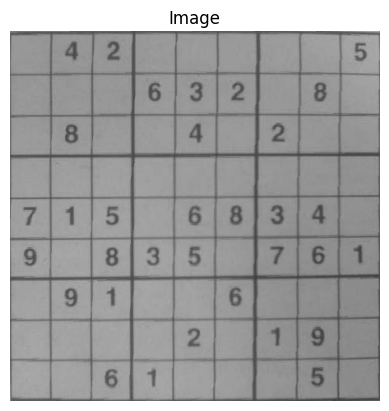

Unsolved board:
. 4 2 | . . . | . . 5 
. . . | 6 3 2 | . 8 . 
. 8 . | . 4 . | 2 . . 
------+-------+------
. . . | . . . | . . . 
7 1 5 | . 6 8 | 3 4 . 
9 . 8 | 3 5 . | 7 6 1 
------+-------+------
. 9 1 | . . 6 | . . . 
. . . | . 2 . | 1 9 . 
. . 6 | 1 . . | . 5 . 

Solved board:
3 4 2 | 8 9 1 | 6 7 5 
1 5 7 | 6 3 2 | 9 8 4 
6 8 9 | 7 4 5 | 2 1 3 
------+-------+------
4 6 3 | 9 1 7 | 5 2 8 
7 1 5 | 2 6 8 | 3 4 9 
9 2 8 | 3 5 4 | 7 6 1 
------+-------+------
5 9 1 | 4 7 6 | 8 3 2 
8 7 4 | 5 2 3 | 1 9 6 
2 3 6 | 1 8 9 | 4 5 7 


In [47]:
def recognize_digits(cells):
    board = []
    for i in range(9):
        row = []
        for j in range(9):
            cell_img, is_empty = cells[i * 9 + j]
            if is_empty:
                row.append(".")
            else:
                cell_normalized = normalize_cell(cell_img)
                features = extract_features([cell_normalized])
                digit = model.predict(features)[0]
                row.append(str(digit))
        board.append(row)
    return board

final_board_img = rotate_board(board_img, best_rotation)
display_image_grayscale(final_board_img)
final_cells = extract_sudoku_cells(final_board_img)
board = recognize_digits(final_cells)
print("Unsolved board:")
display_board(board)

if is_valid_sudoku(board):
    solve_sudoku(board)
    print()
    print("Solved board:")
    display_board(board)
else:
    print("Invalid board — digit recognition may have errors or the board is impossible to solve.")
